In [16]:
import os
os.chdir('/home/jovyan/signal-extraction') # set the current working directory to the base signal-extraction folder so vae and sim files and easily be called.

In [3]:
from vae_code.HD.normVAE_HD import *

# Loading the reanalysis data

In [25]:
sdata1 = xr.open_dataset("./vae_input_data/sst_mon-mean.nc")
pdata1 = xr.open_dataset("./vae_input_data/tp_mon-sum.nc")

print(f"{sdata1}, /n {pdata1}")

<xarray.Dataset> Size: 34MB
Dimensions:          (valid_time: 1026, bnds: 2, latitude: 41, longitude: 201)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 8kB 1940-01-16 ... 2025-06-1...
  * latitude         (latitude) float64 328B 5.0 4.75 4.5 ... -4.5 -4.75 -5.0
  * longitude        (longitude) float64 2kB -170.0 -169.8 ... -120.2 -120.0
Dimensions without coordinates: bnds
Data variables:
    valid_time_bnds  (valid_time, bnds) datetime64[ns] 16kB ...
    sst              (valid_time, latitude, longitude) float32 34MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.1 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Jul 24 17:53:53 2025: CDO monmean ./signal-e...
    frequency:               mon
    CDO:          

# Running the normVAE

Starting run for Dim=2...
Completed run for Dim=2 ✓

Starting run for Dim=3...
Completed run for Dim=3 ✓

Starting run for Dim=4...
Completed run for Dim=4 ✓

Starting run for Dim=5...
Completed run for Dim=5 ✓

Starting run for Dim=6...
Completed run for Dim=6 ✓

Starting run for Dim=7...
Completed run for Dim=7 ✓



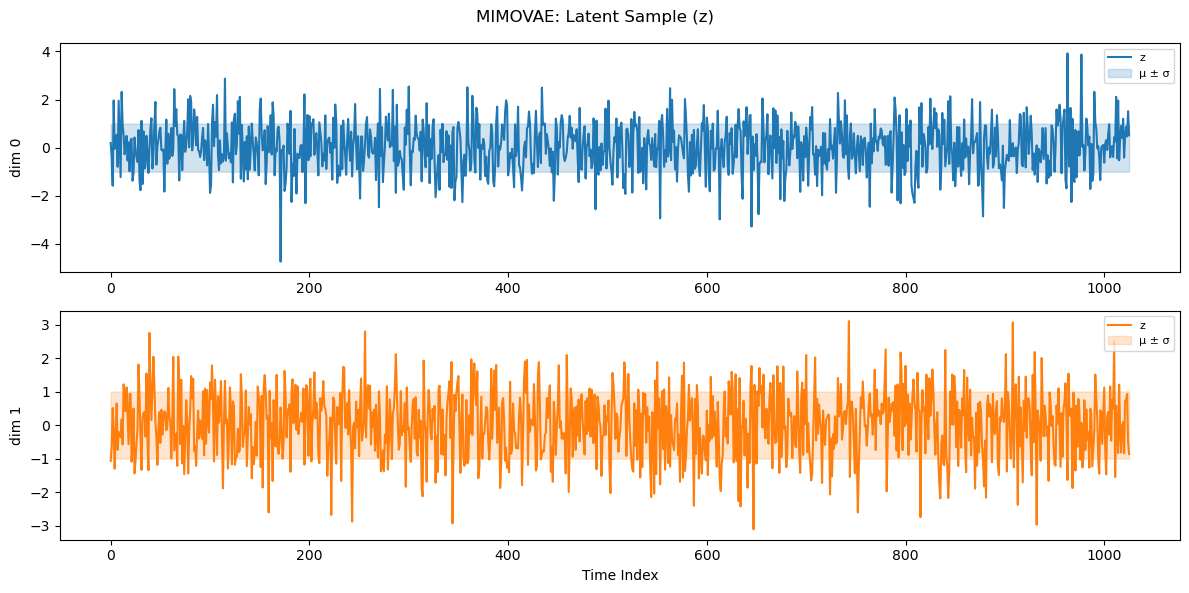

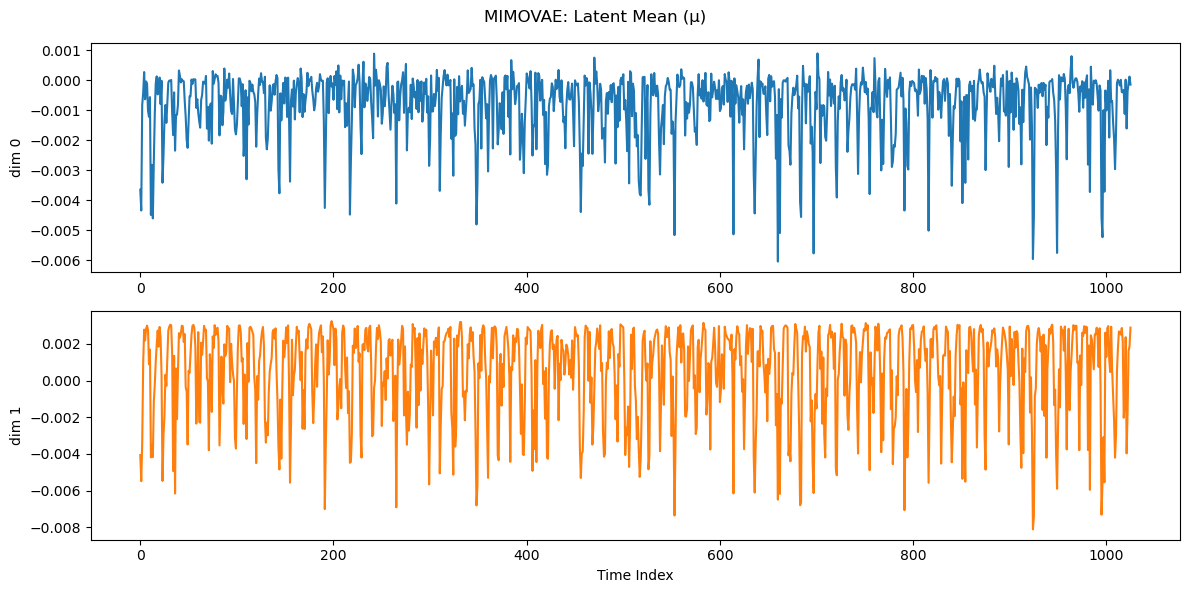

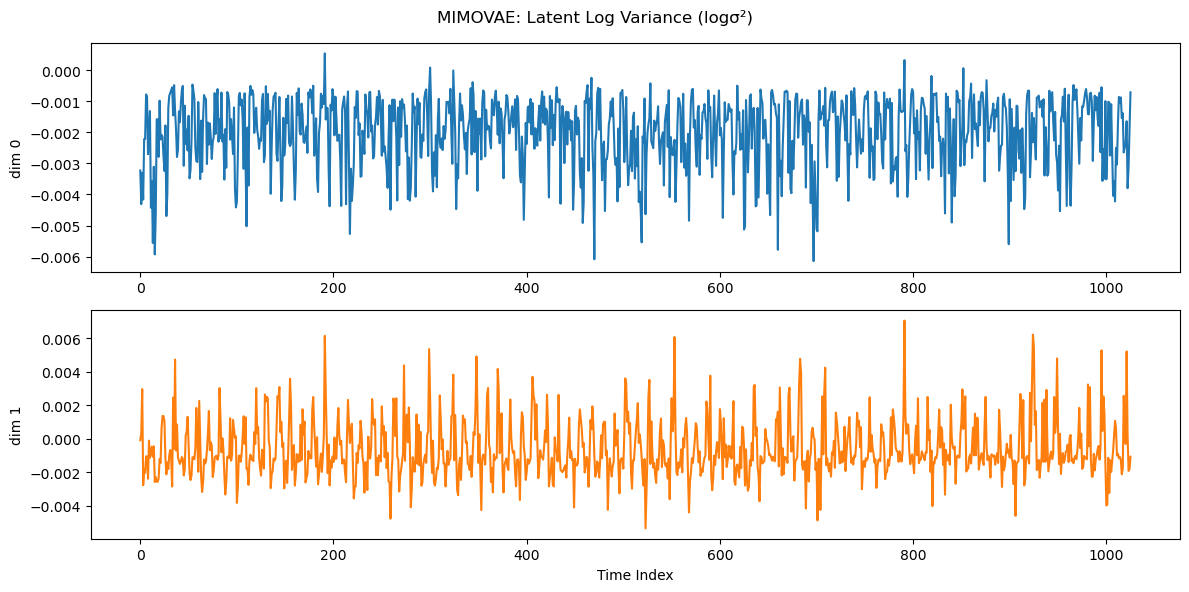

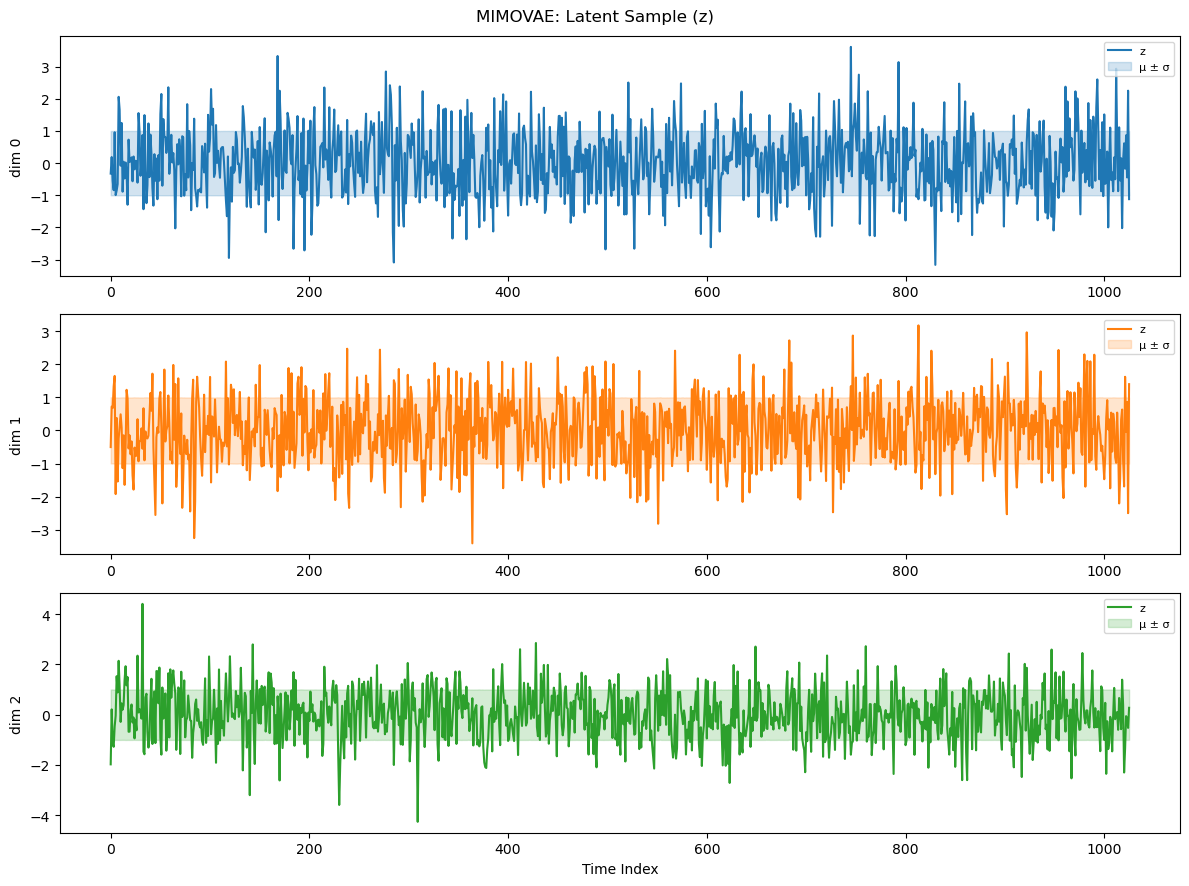

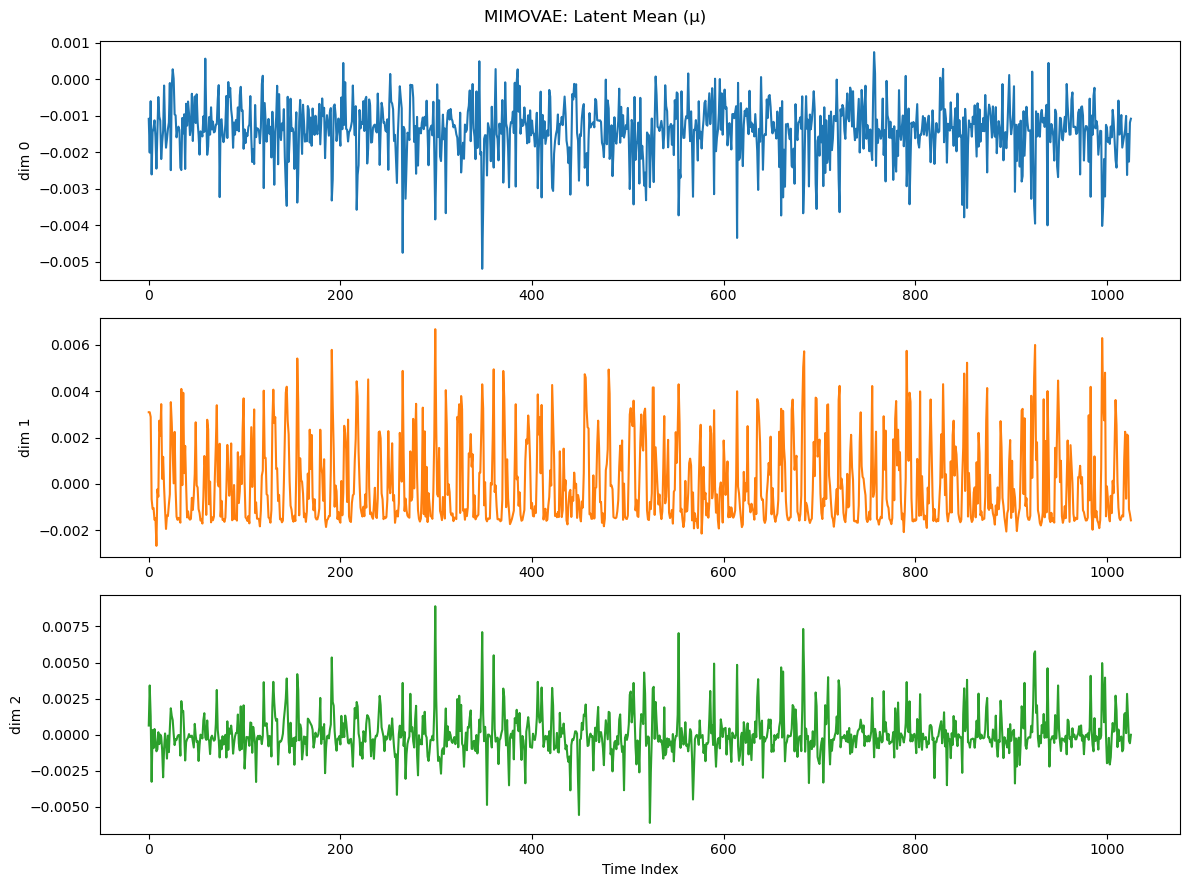

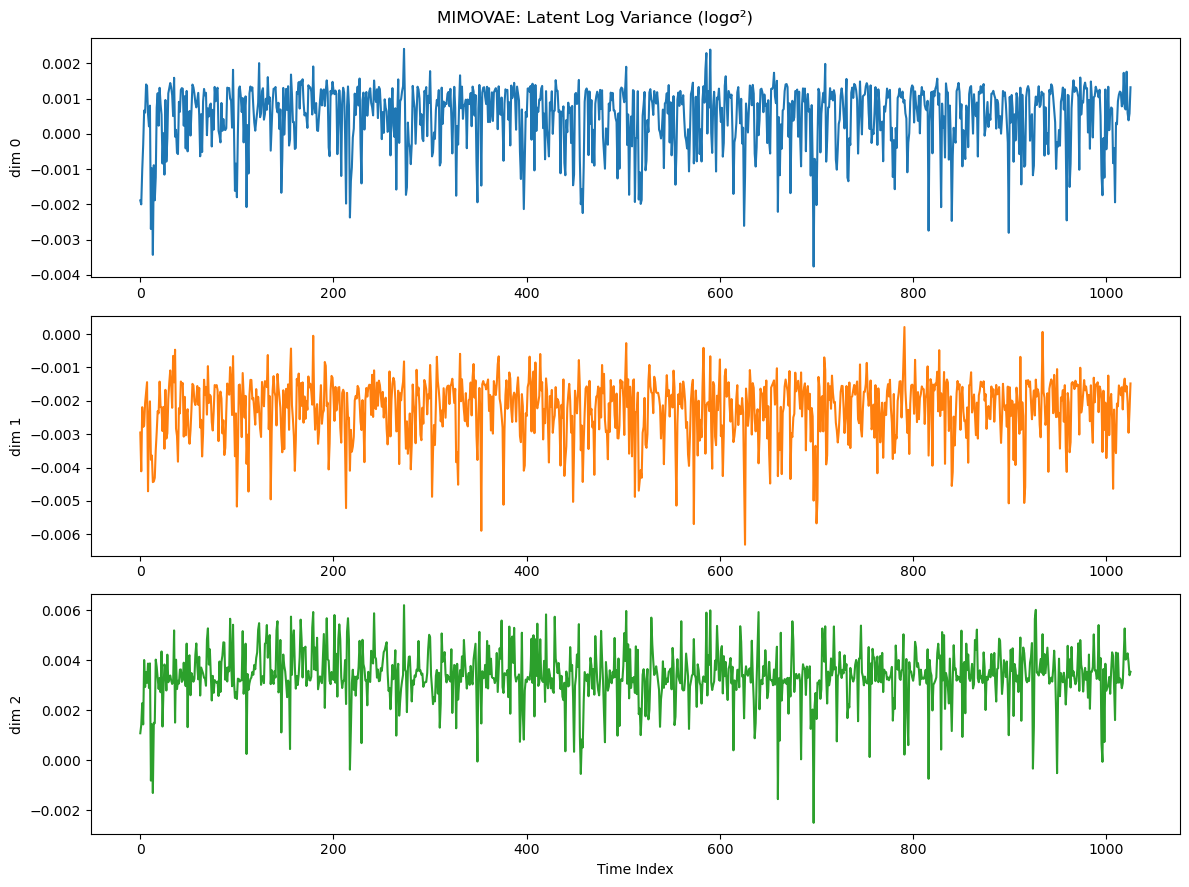

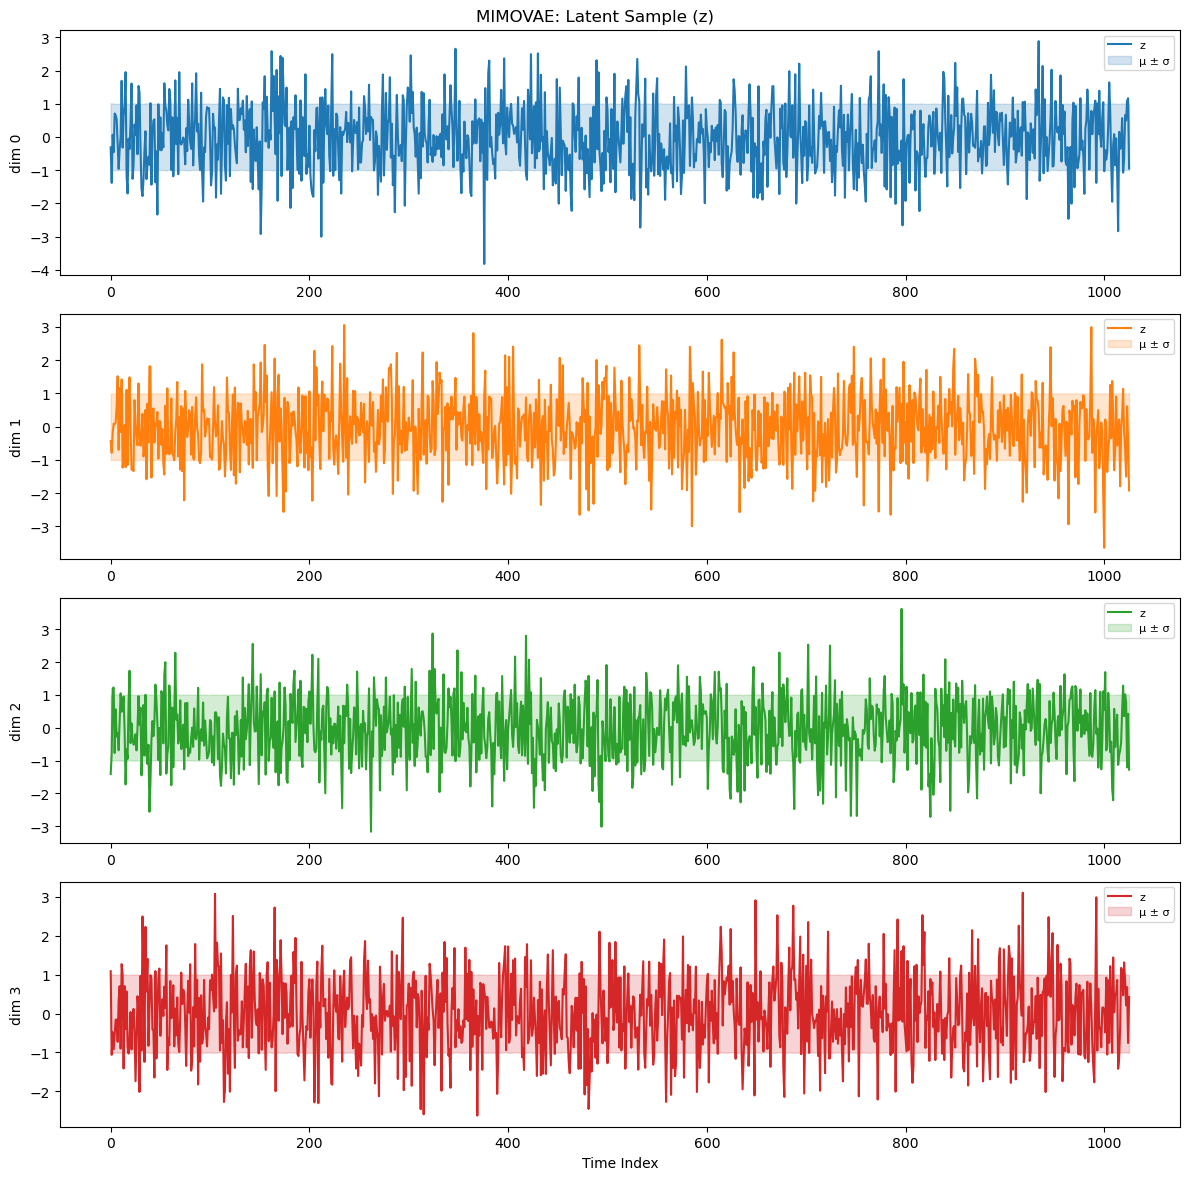

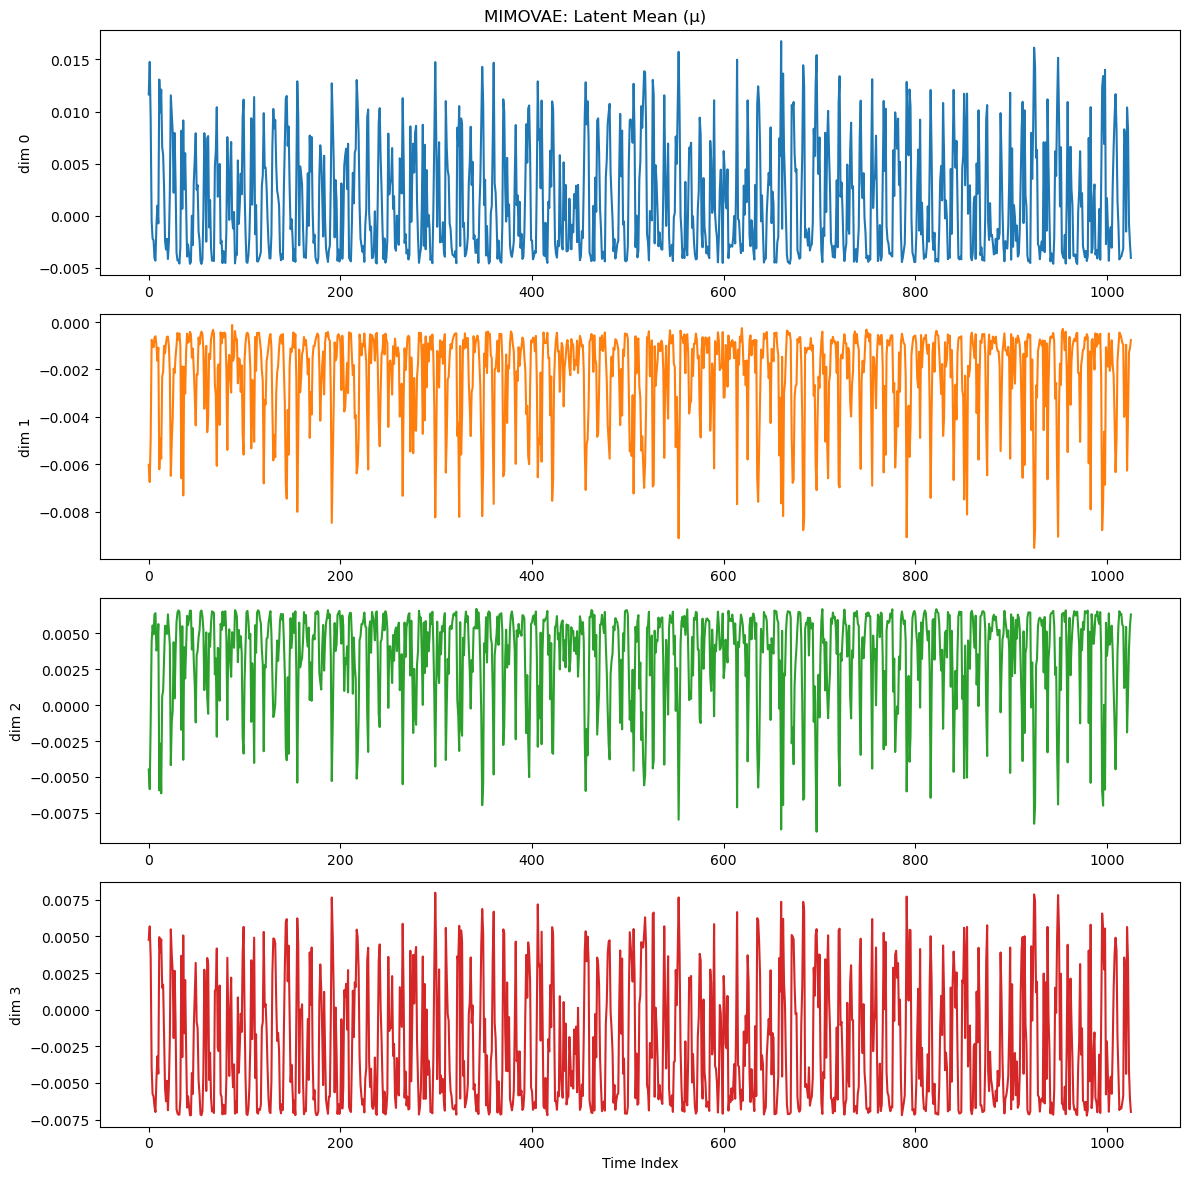

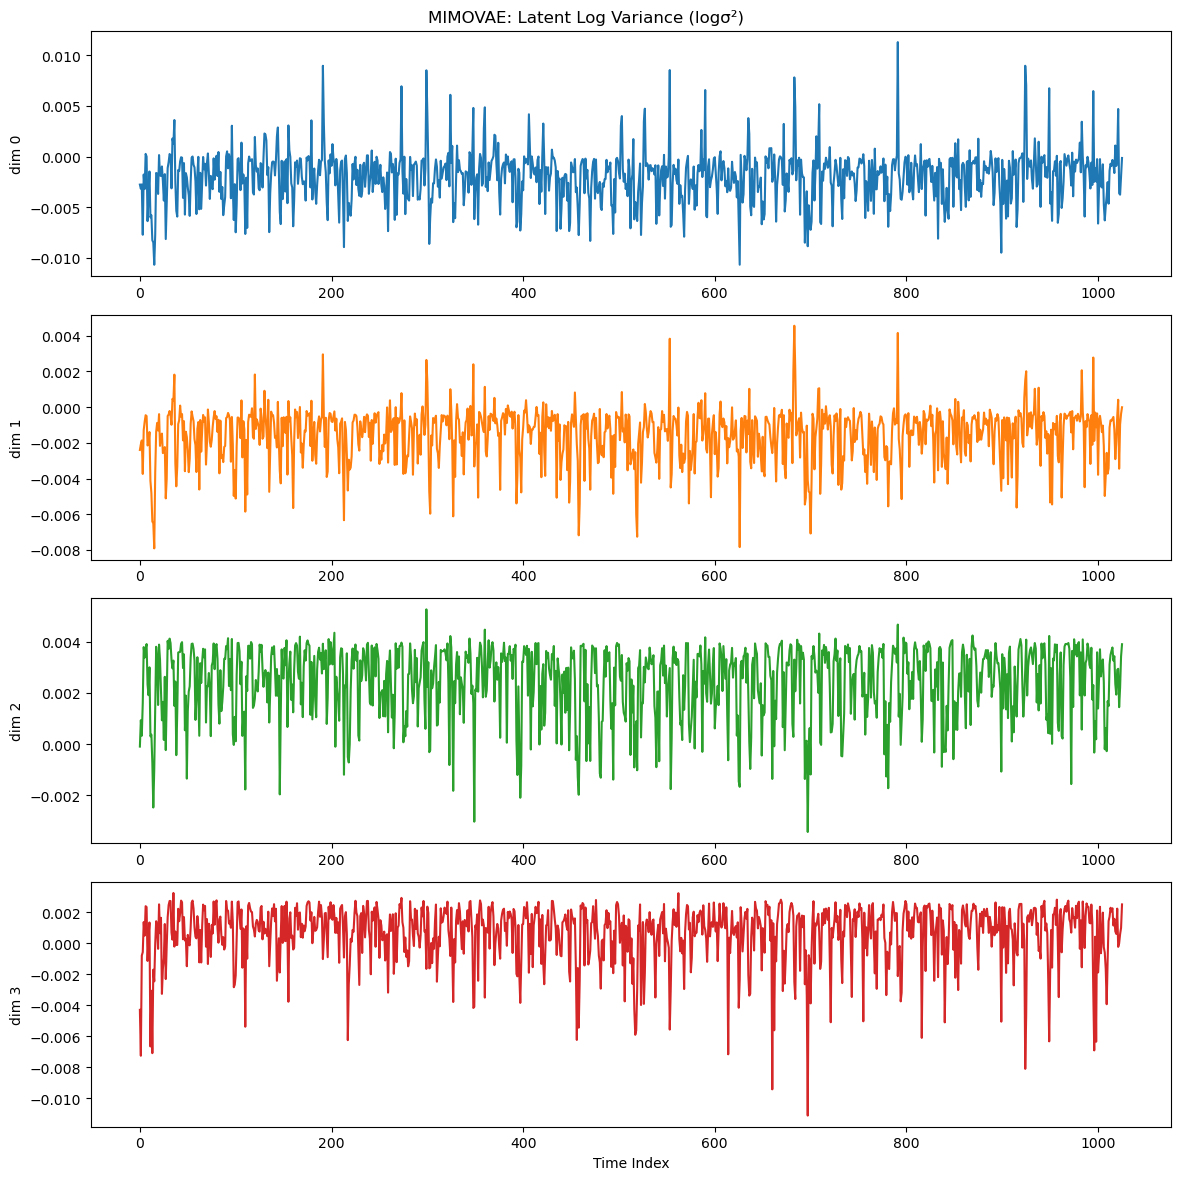

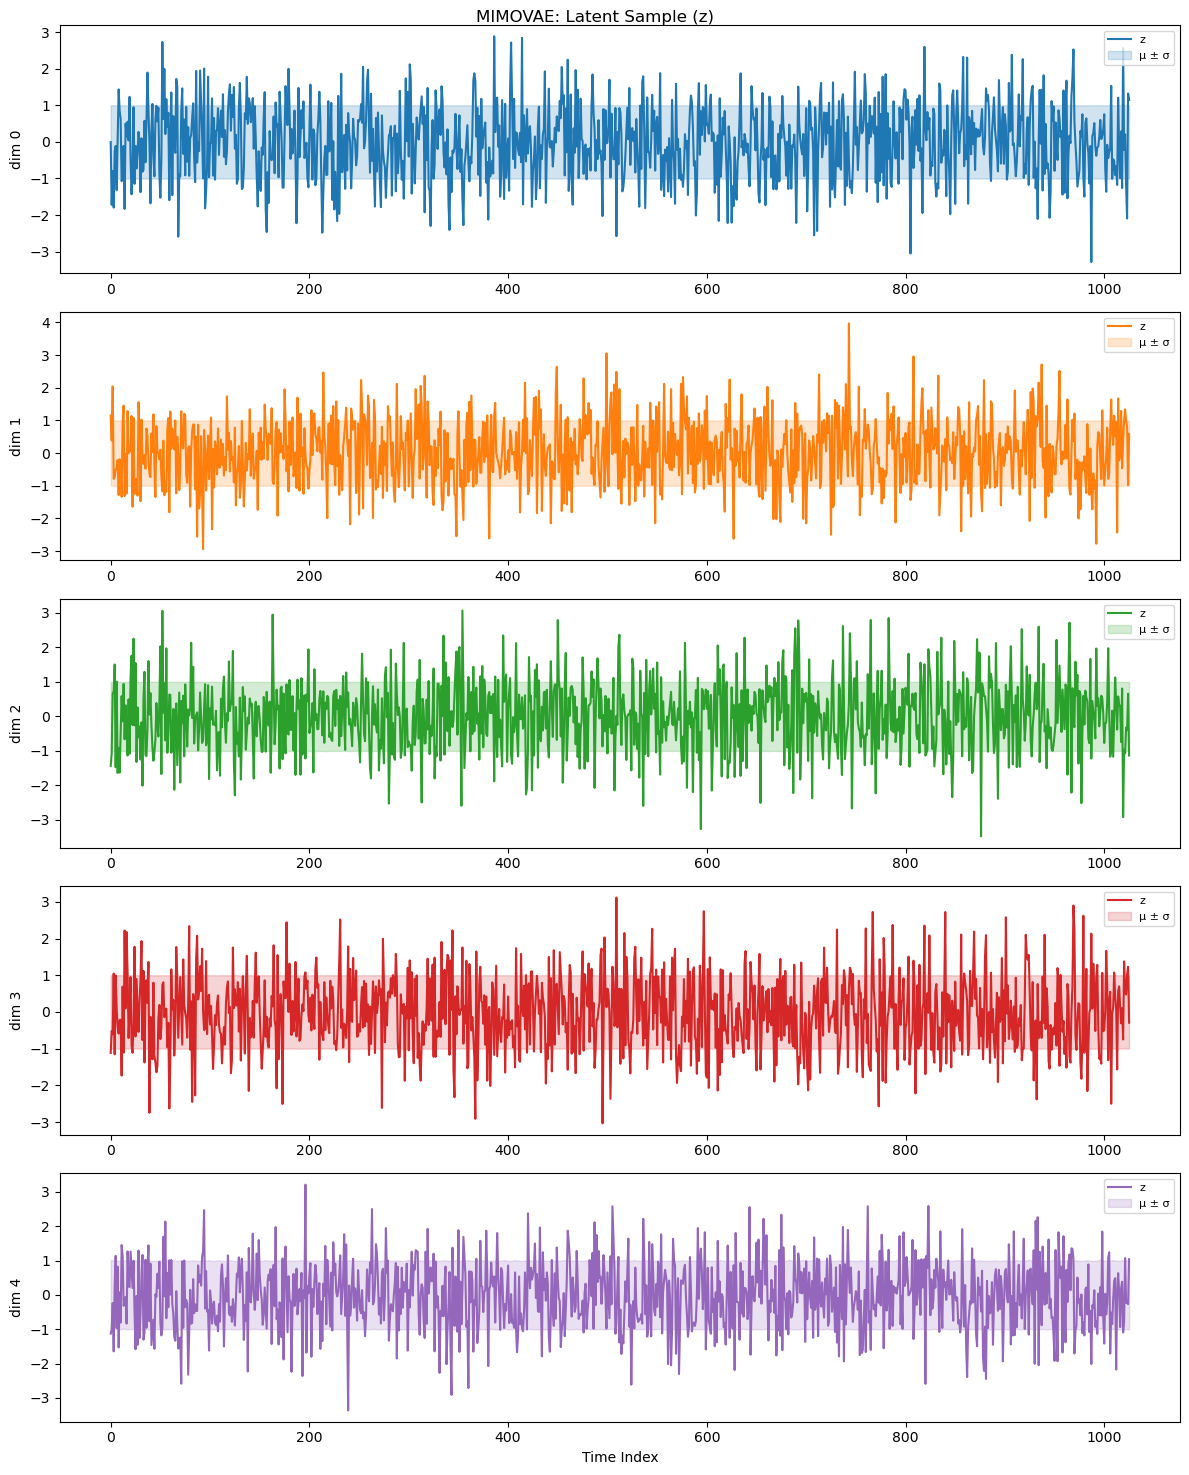

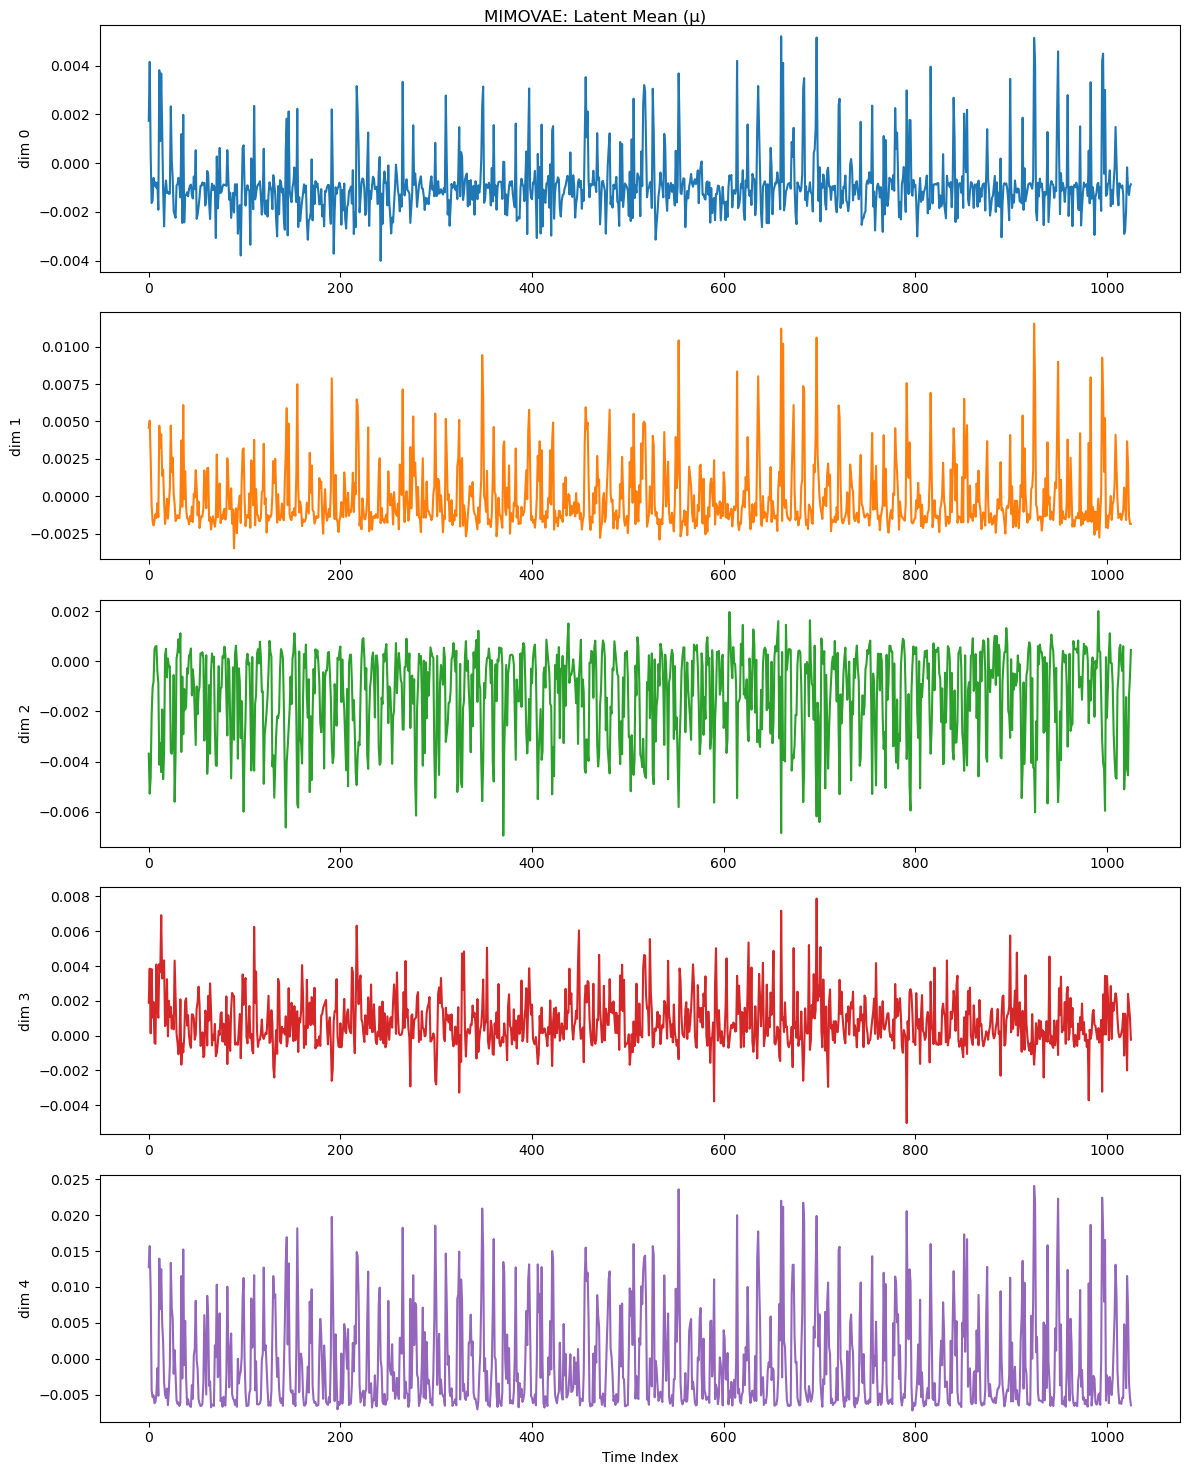

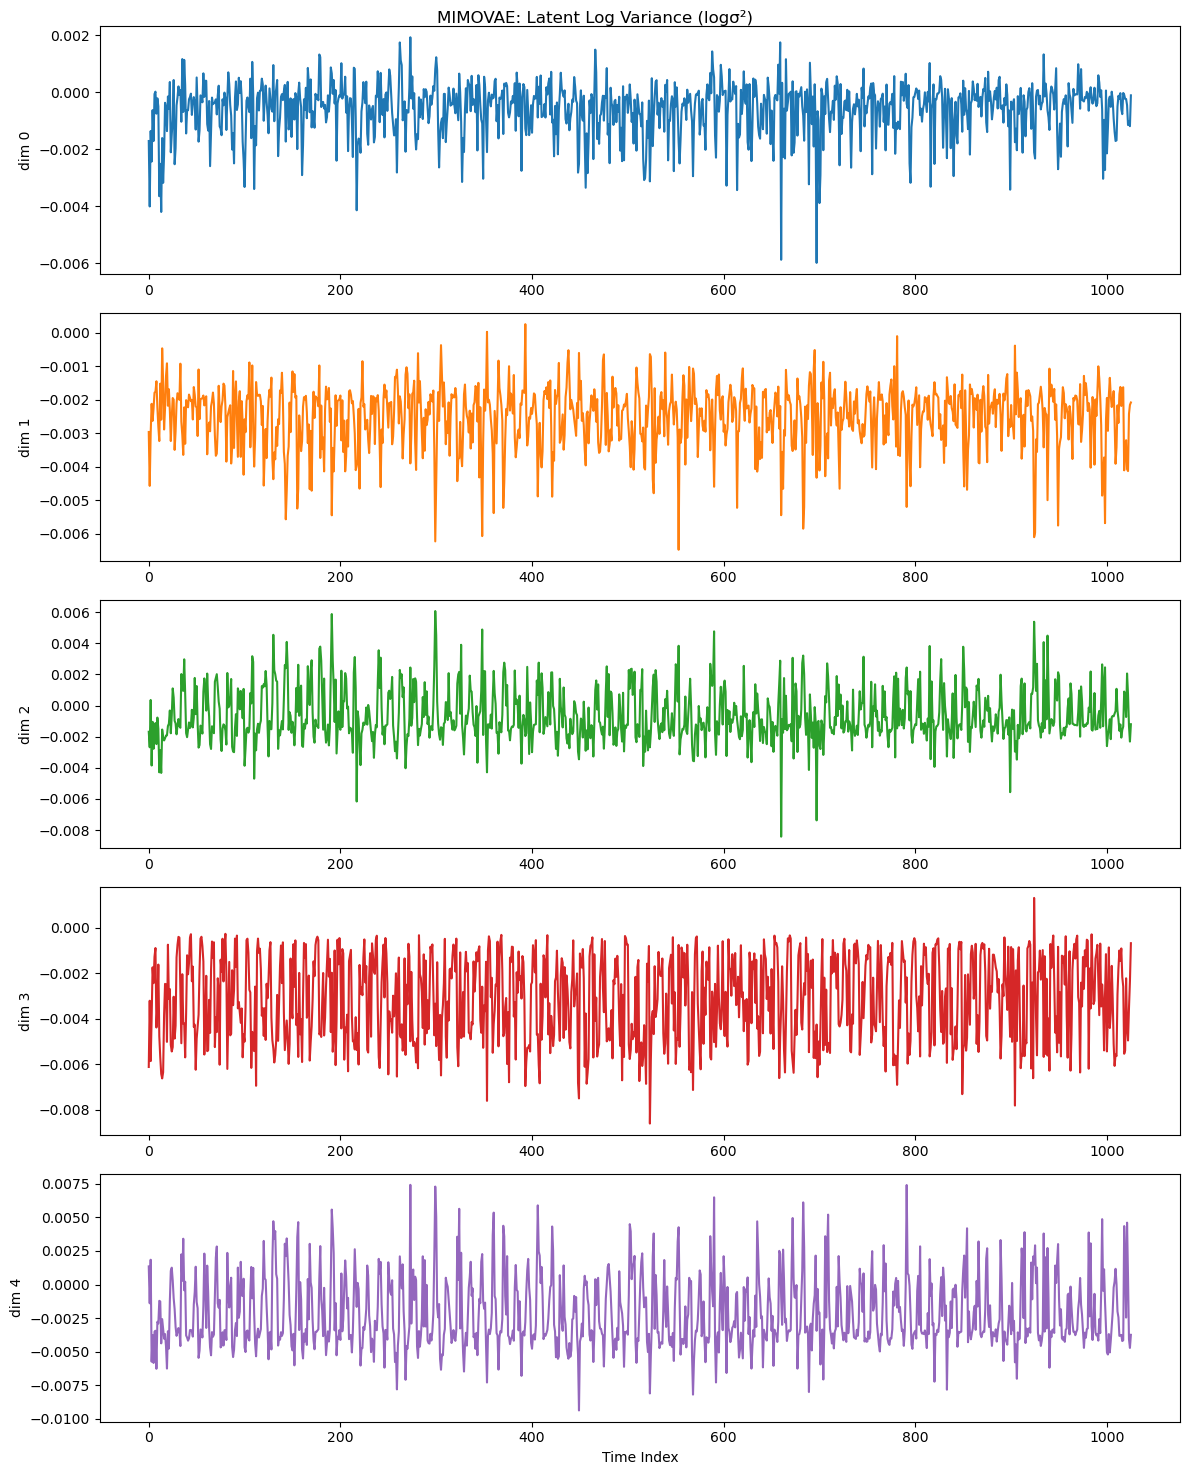

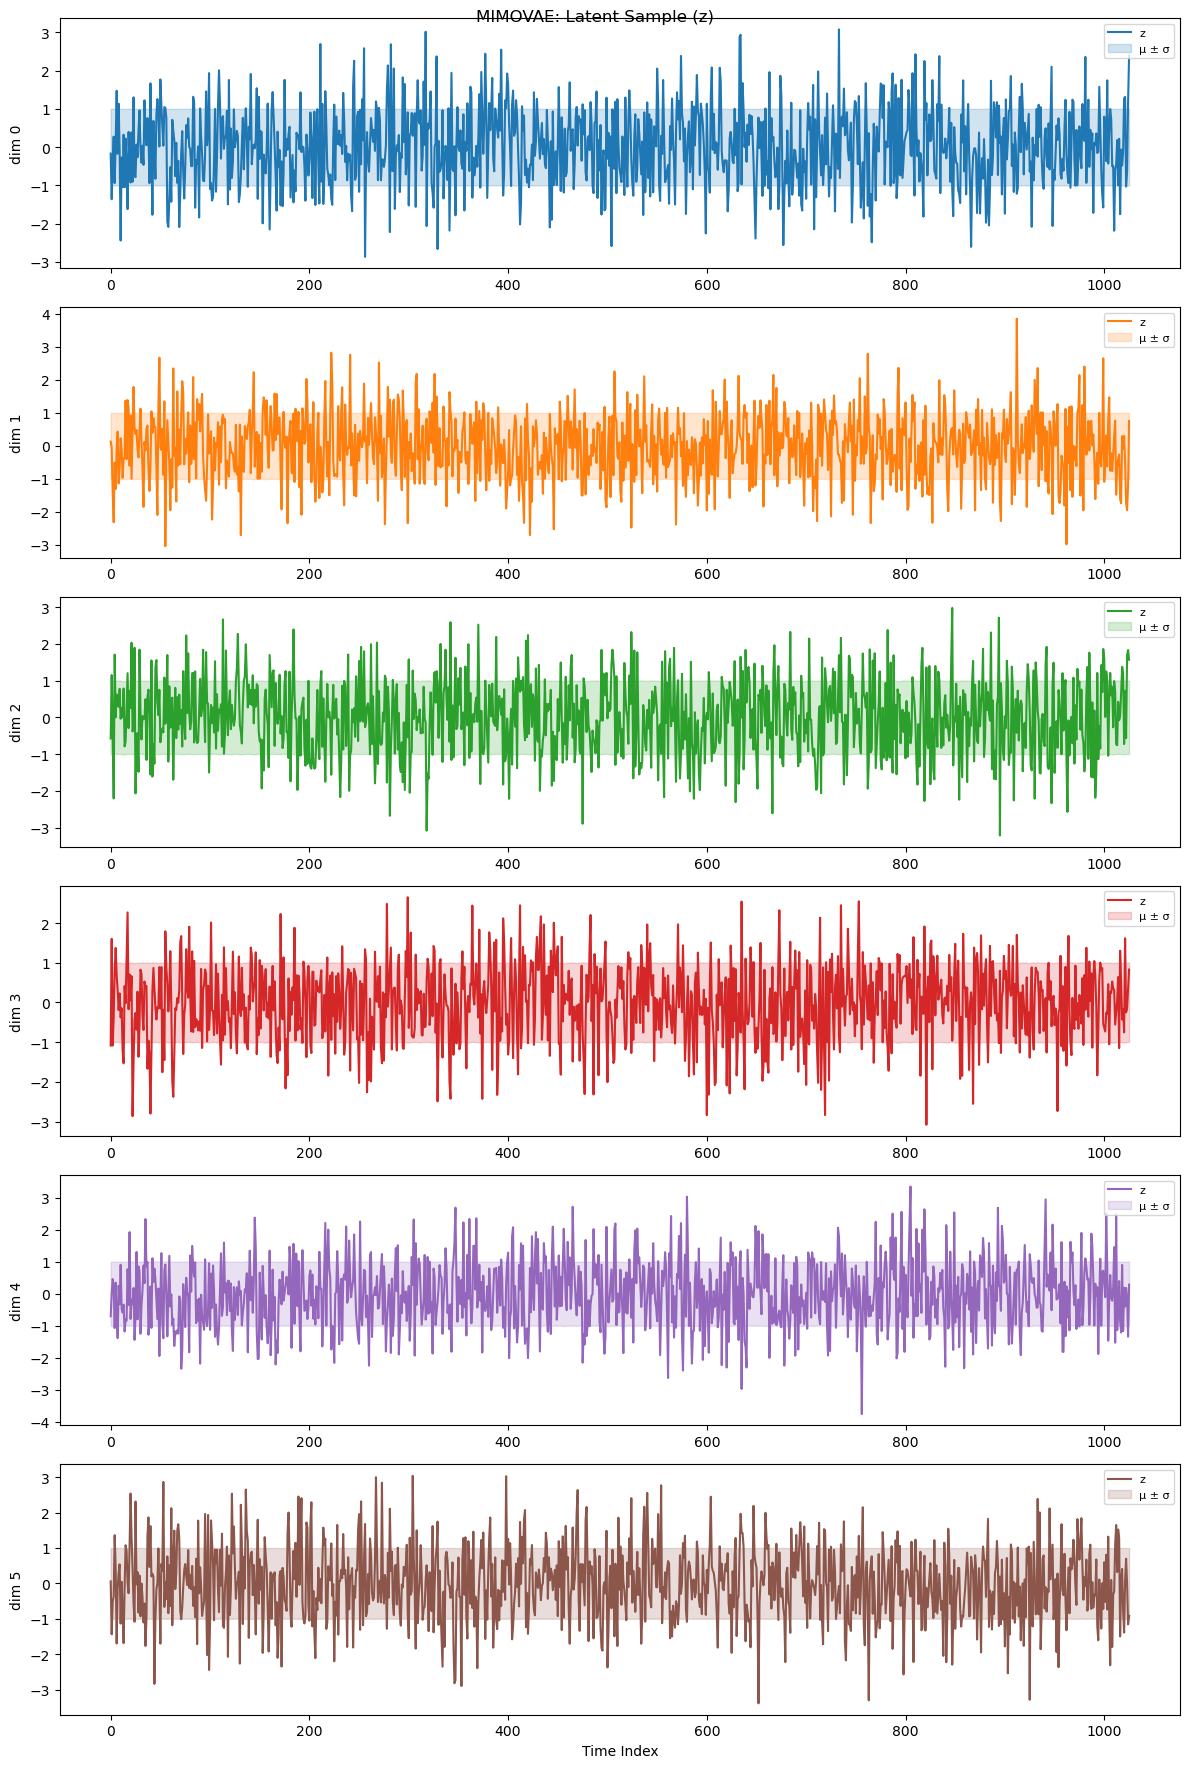

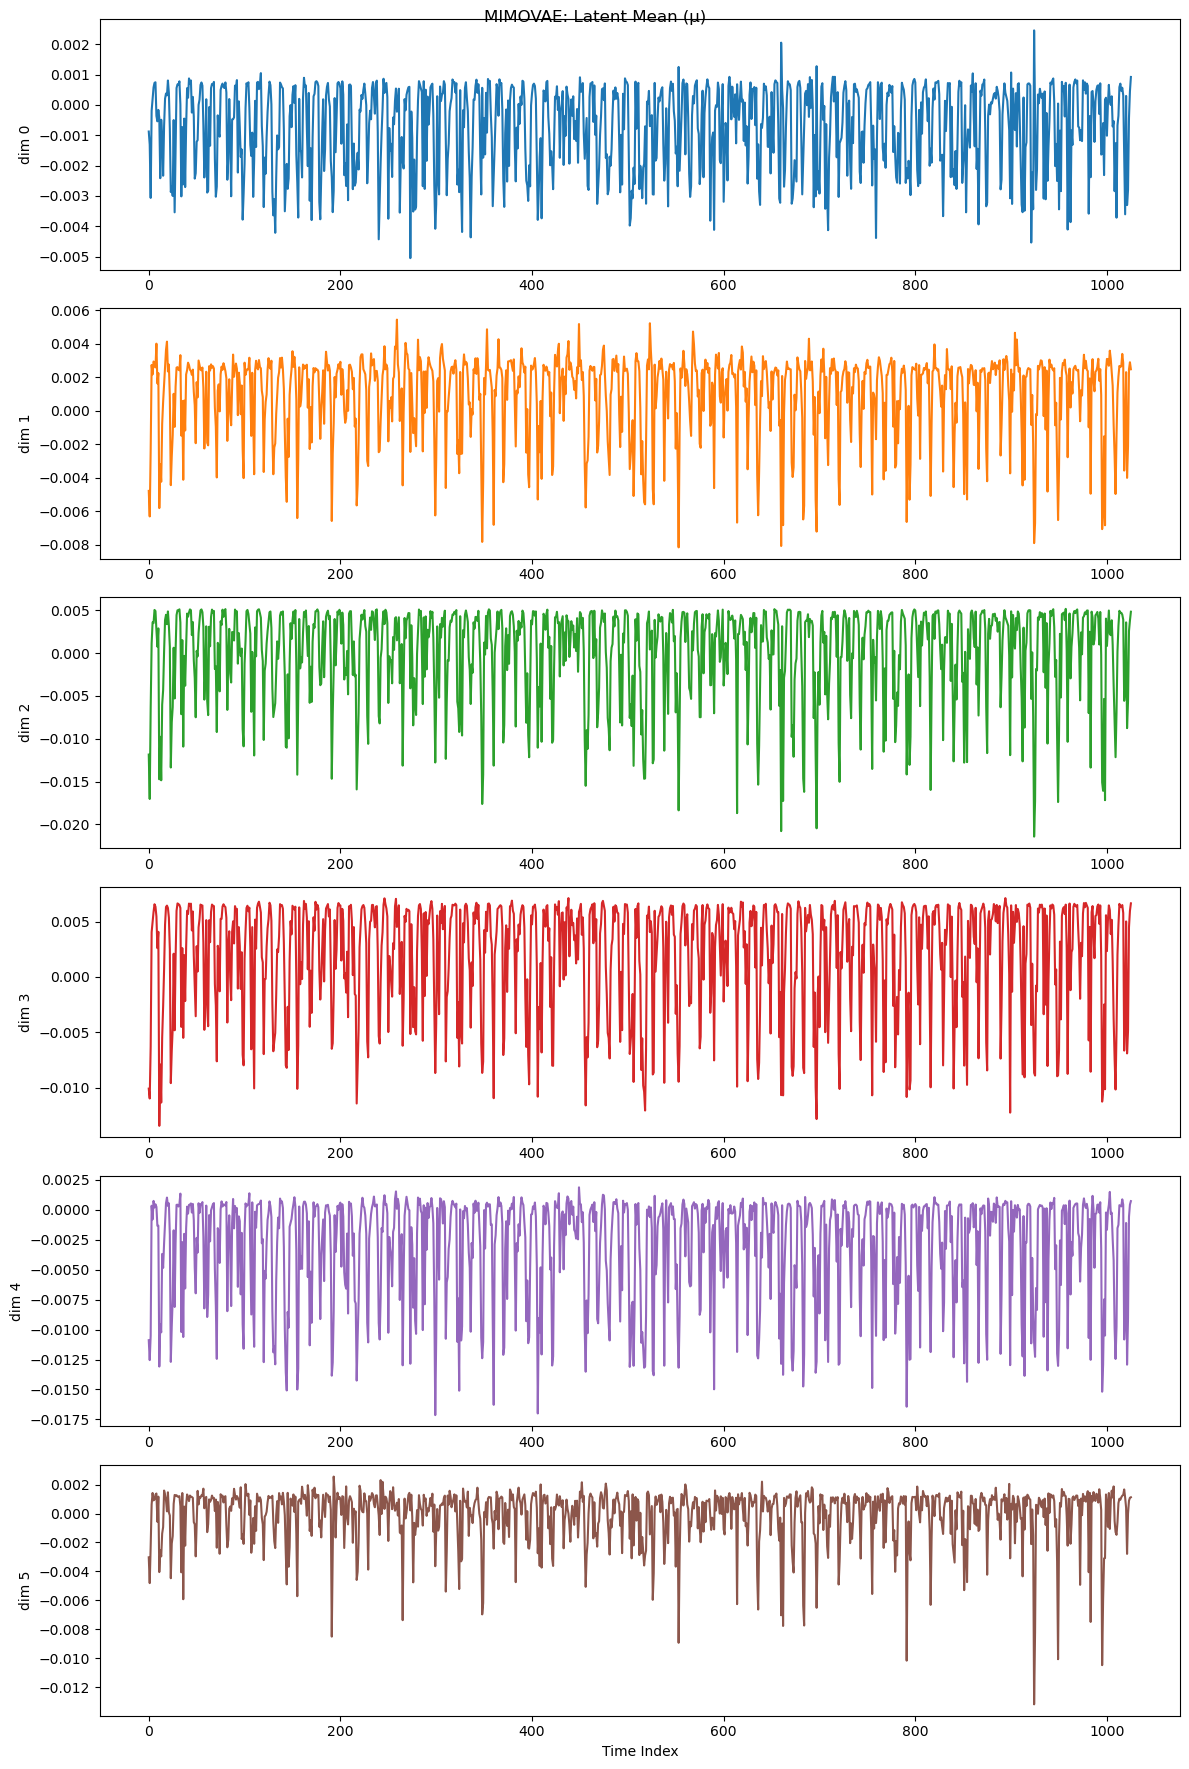

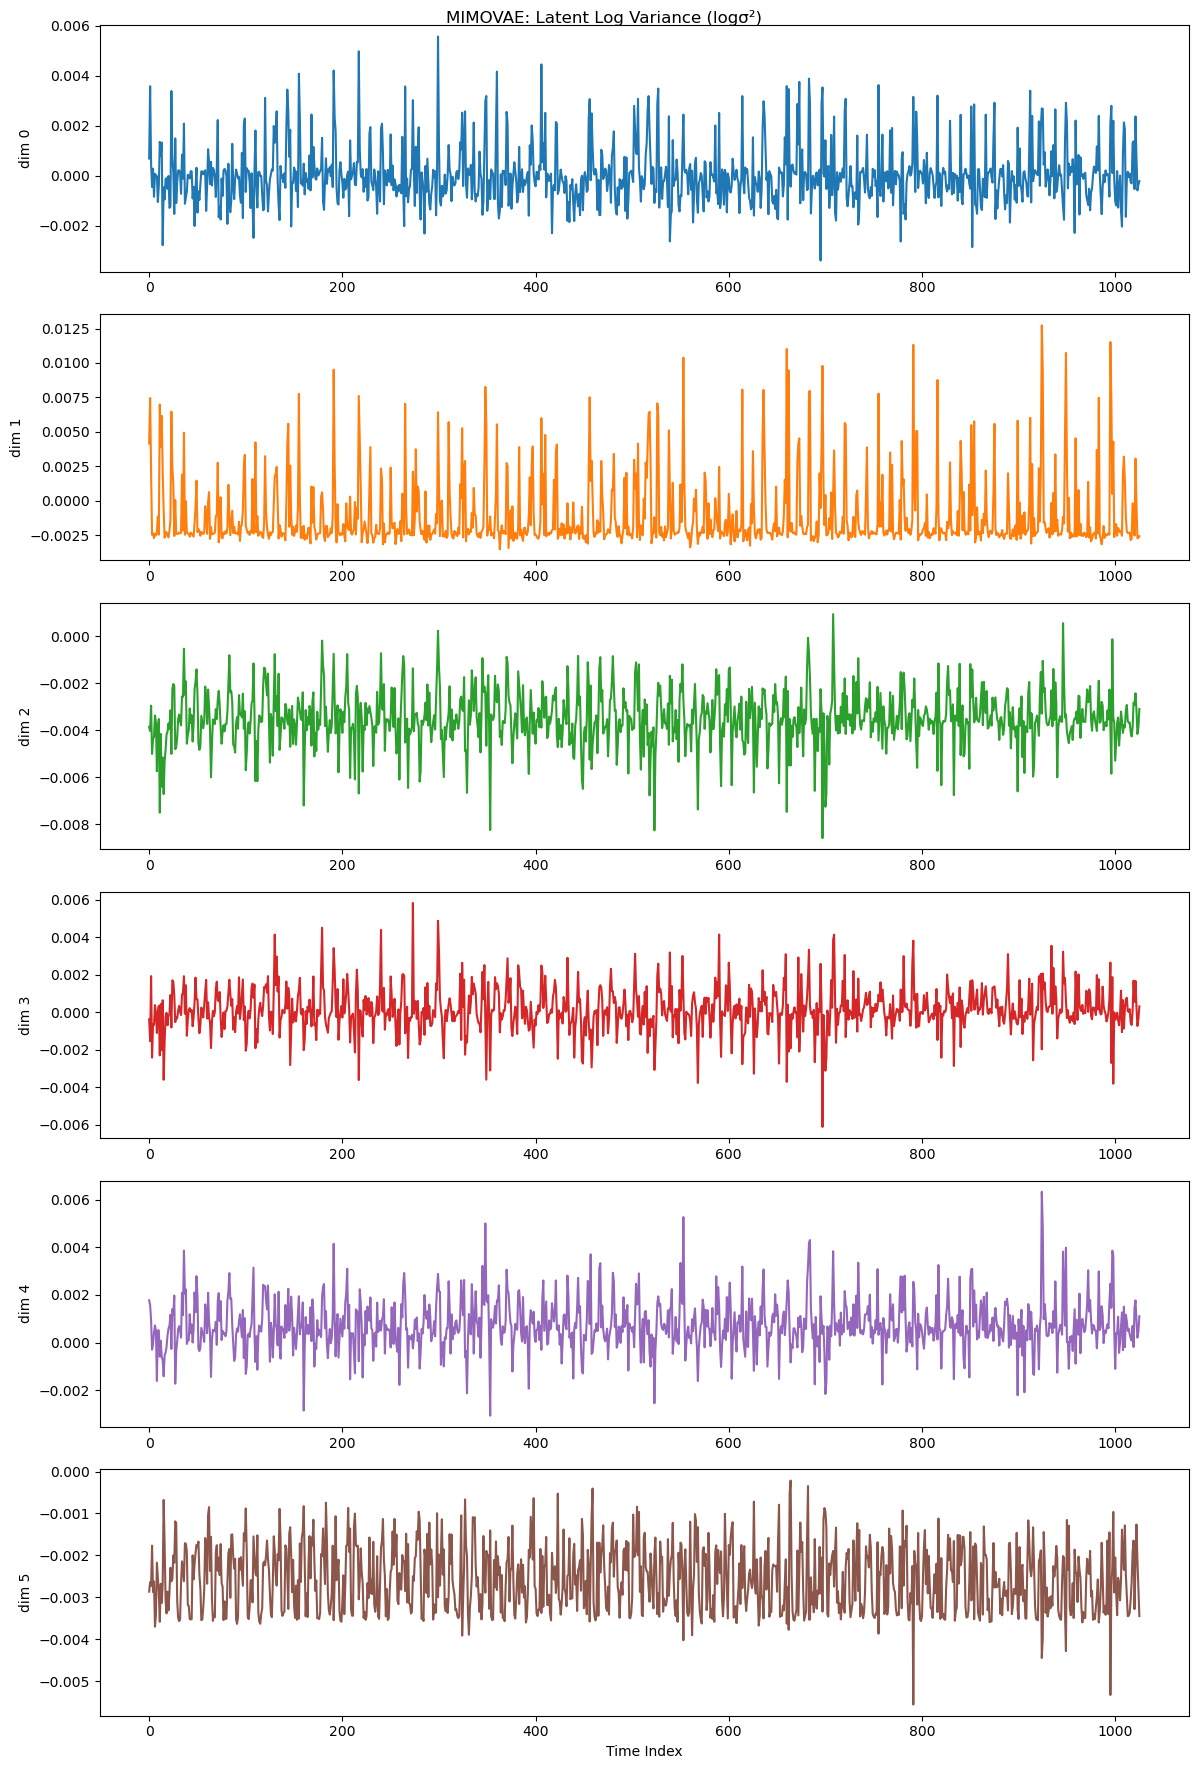

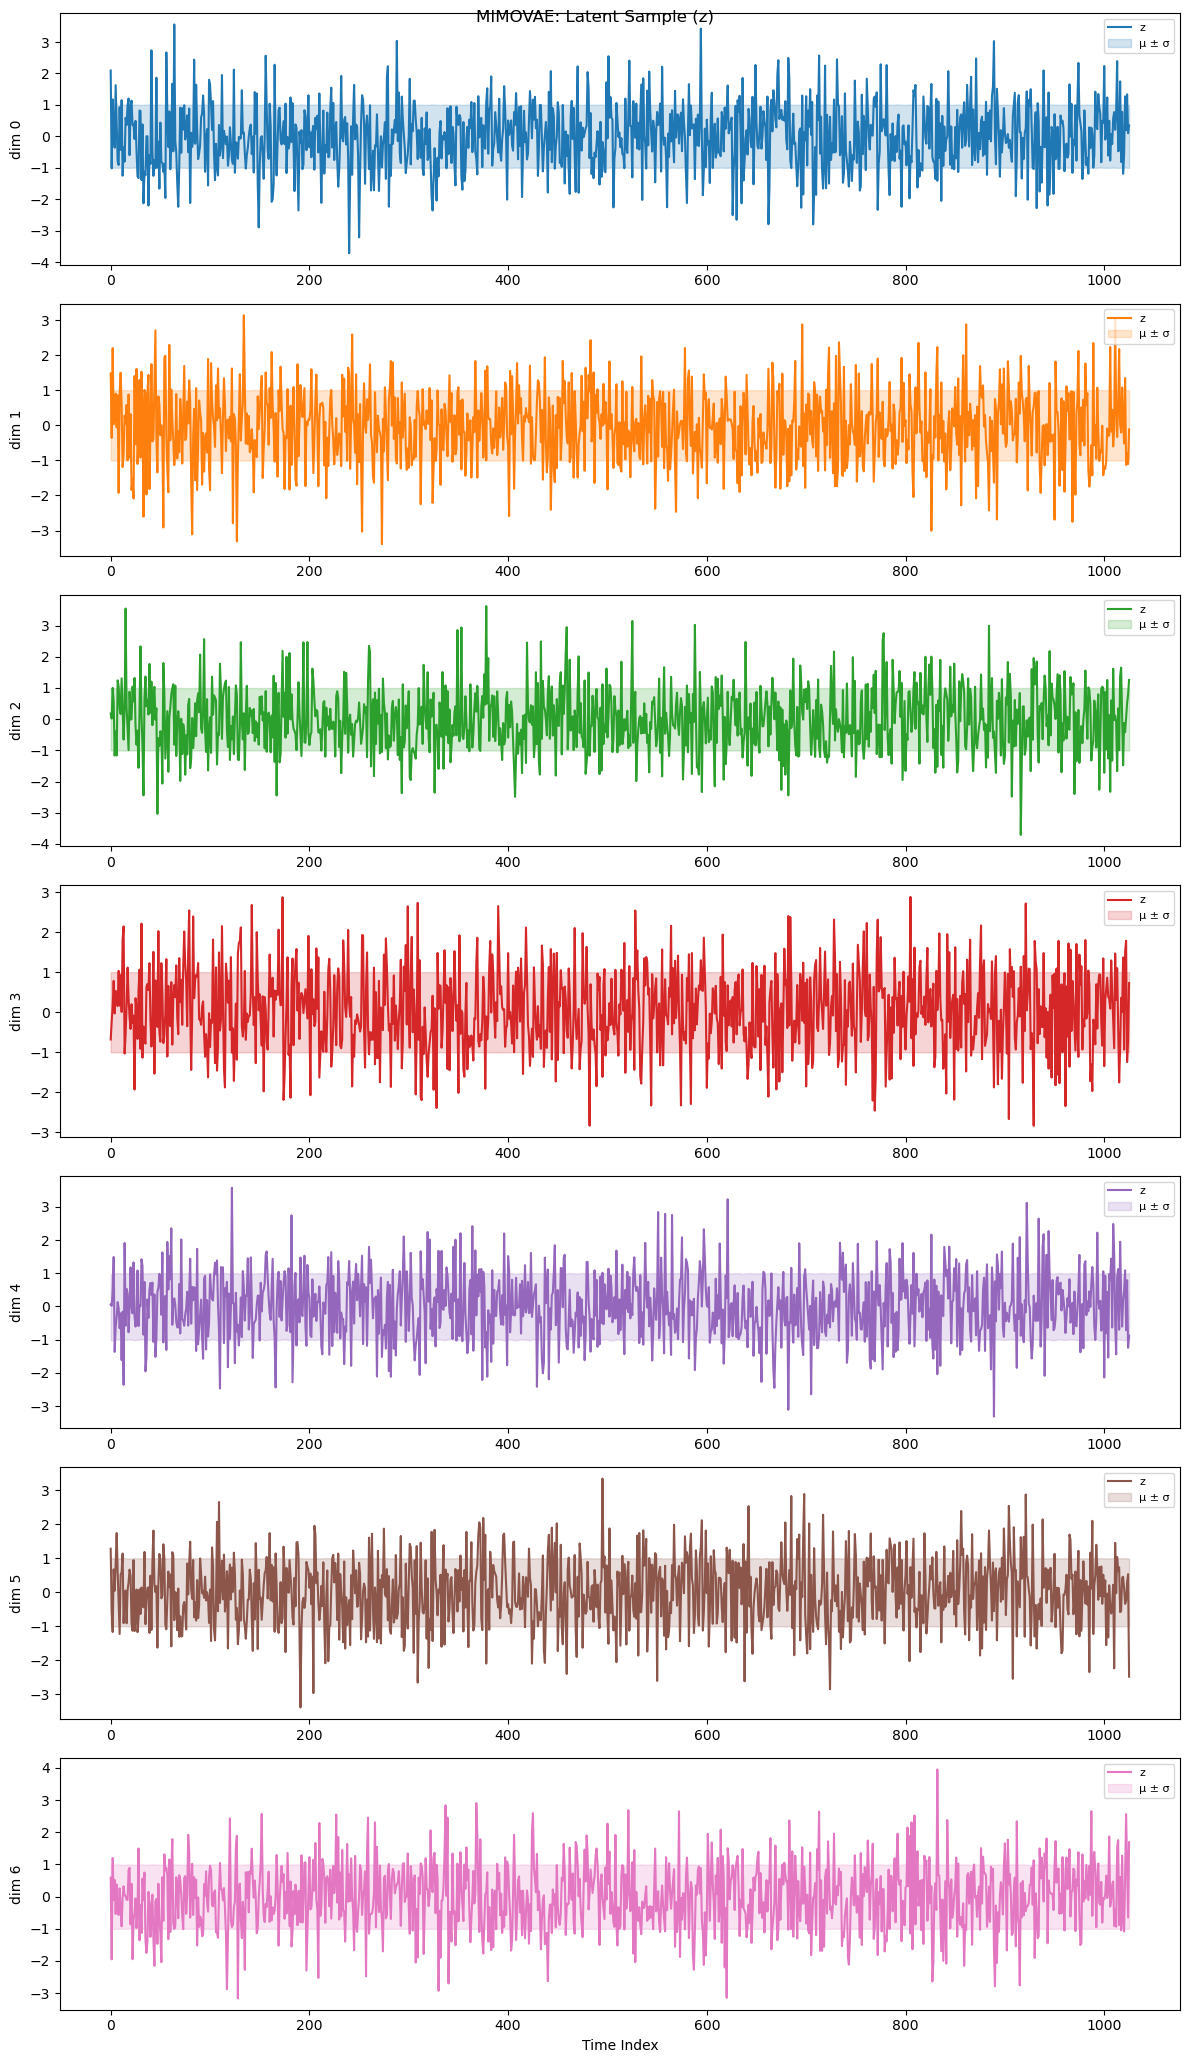

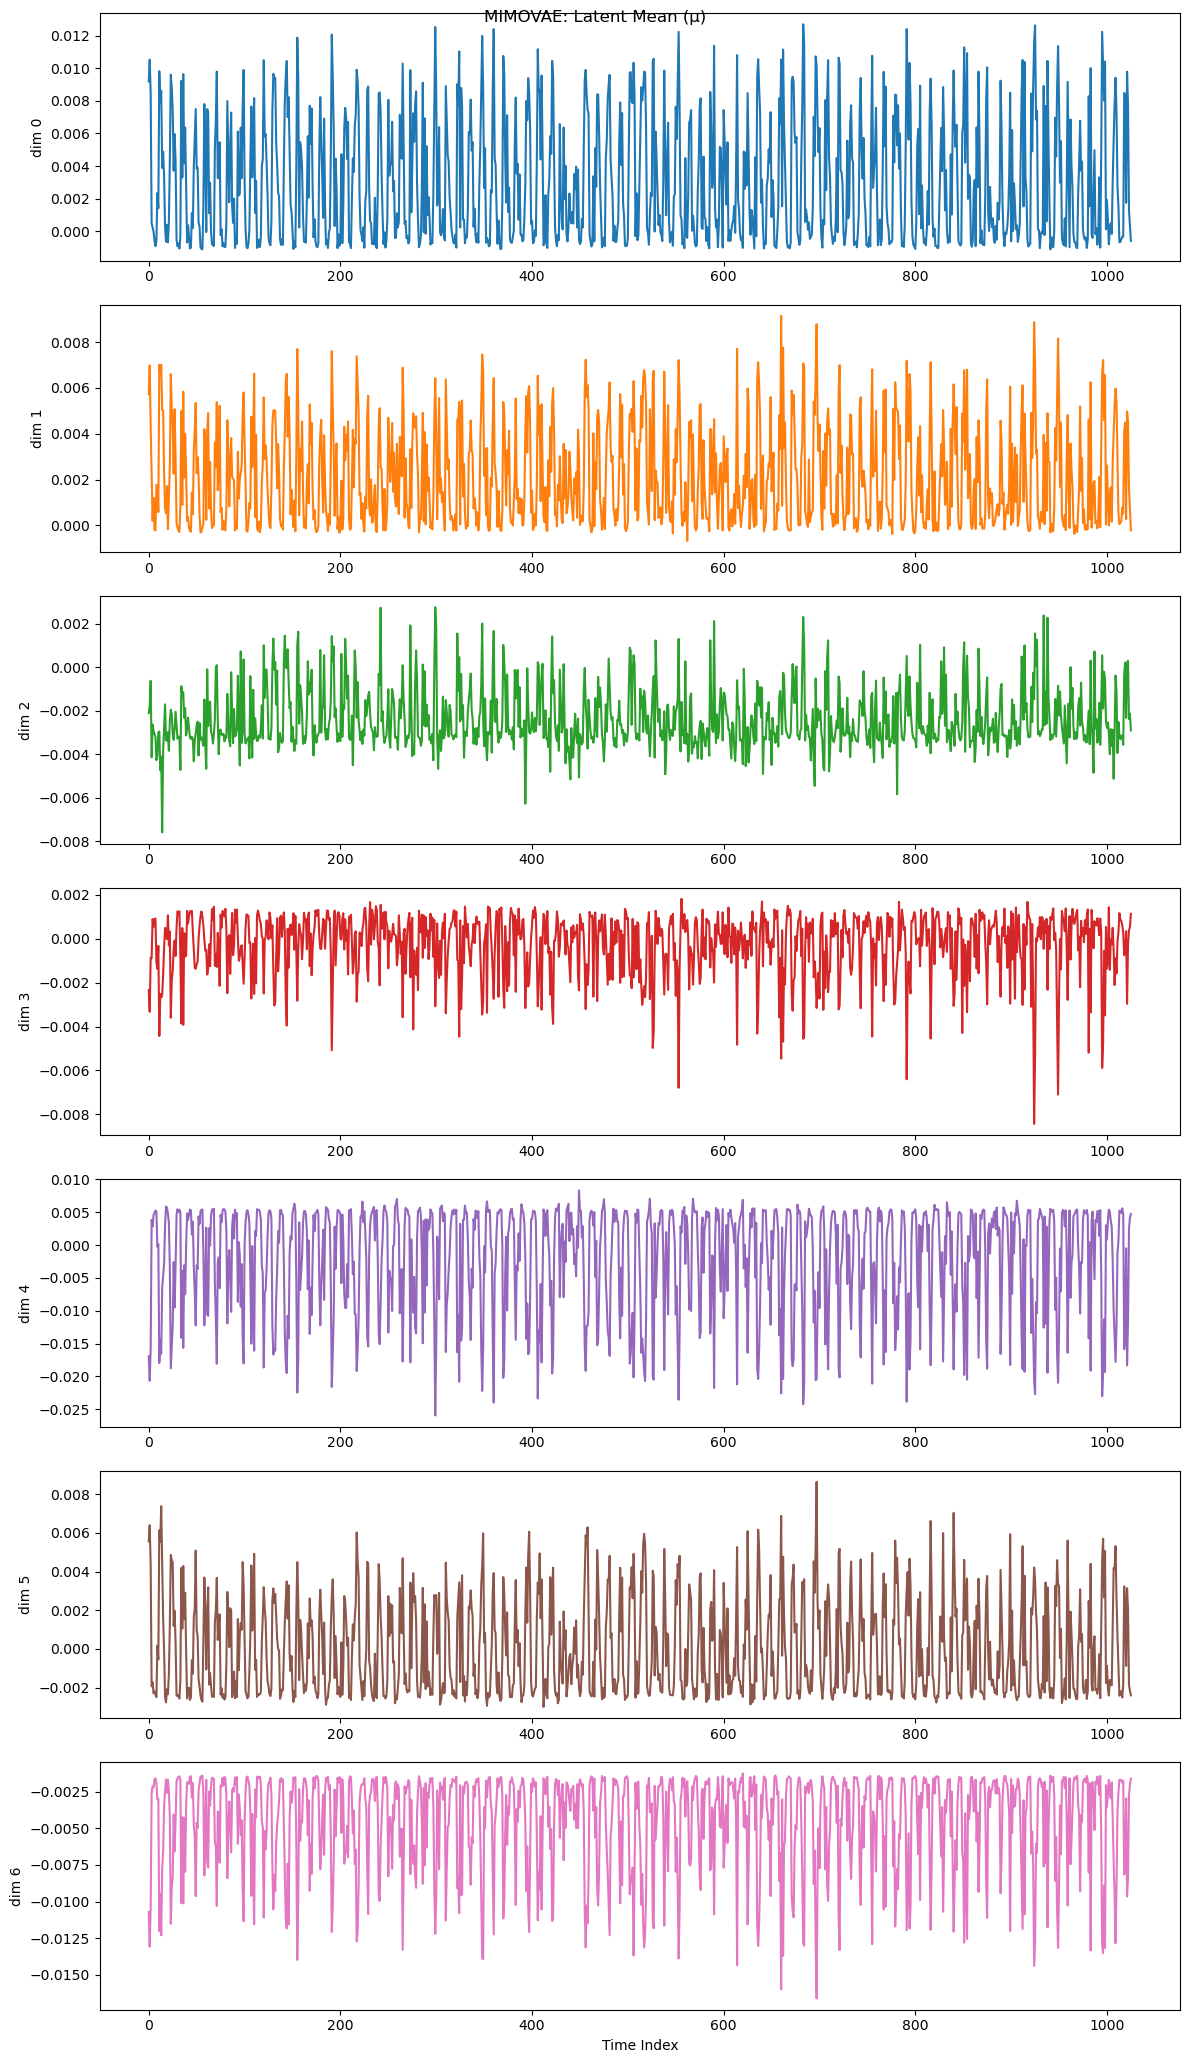

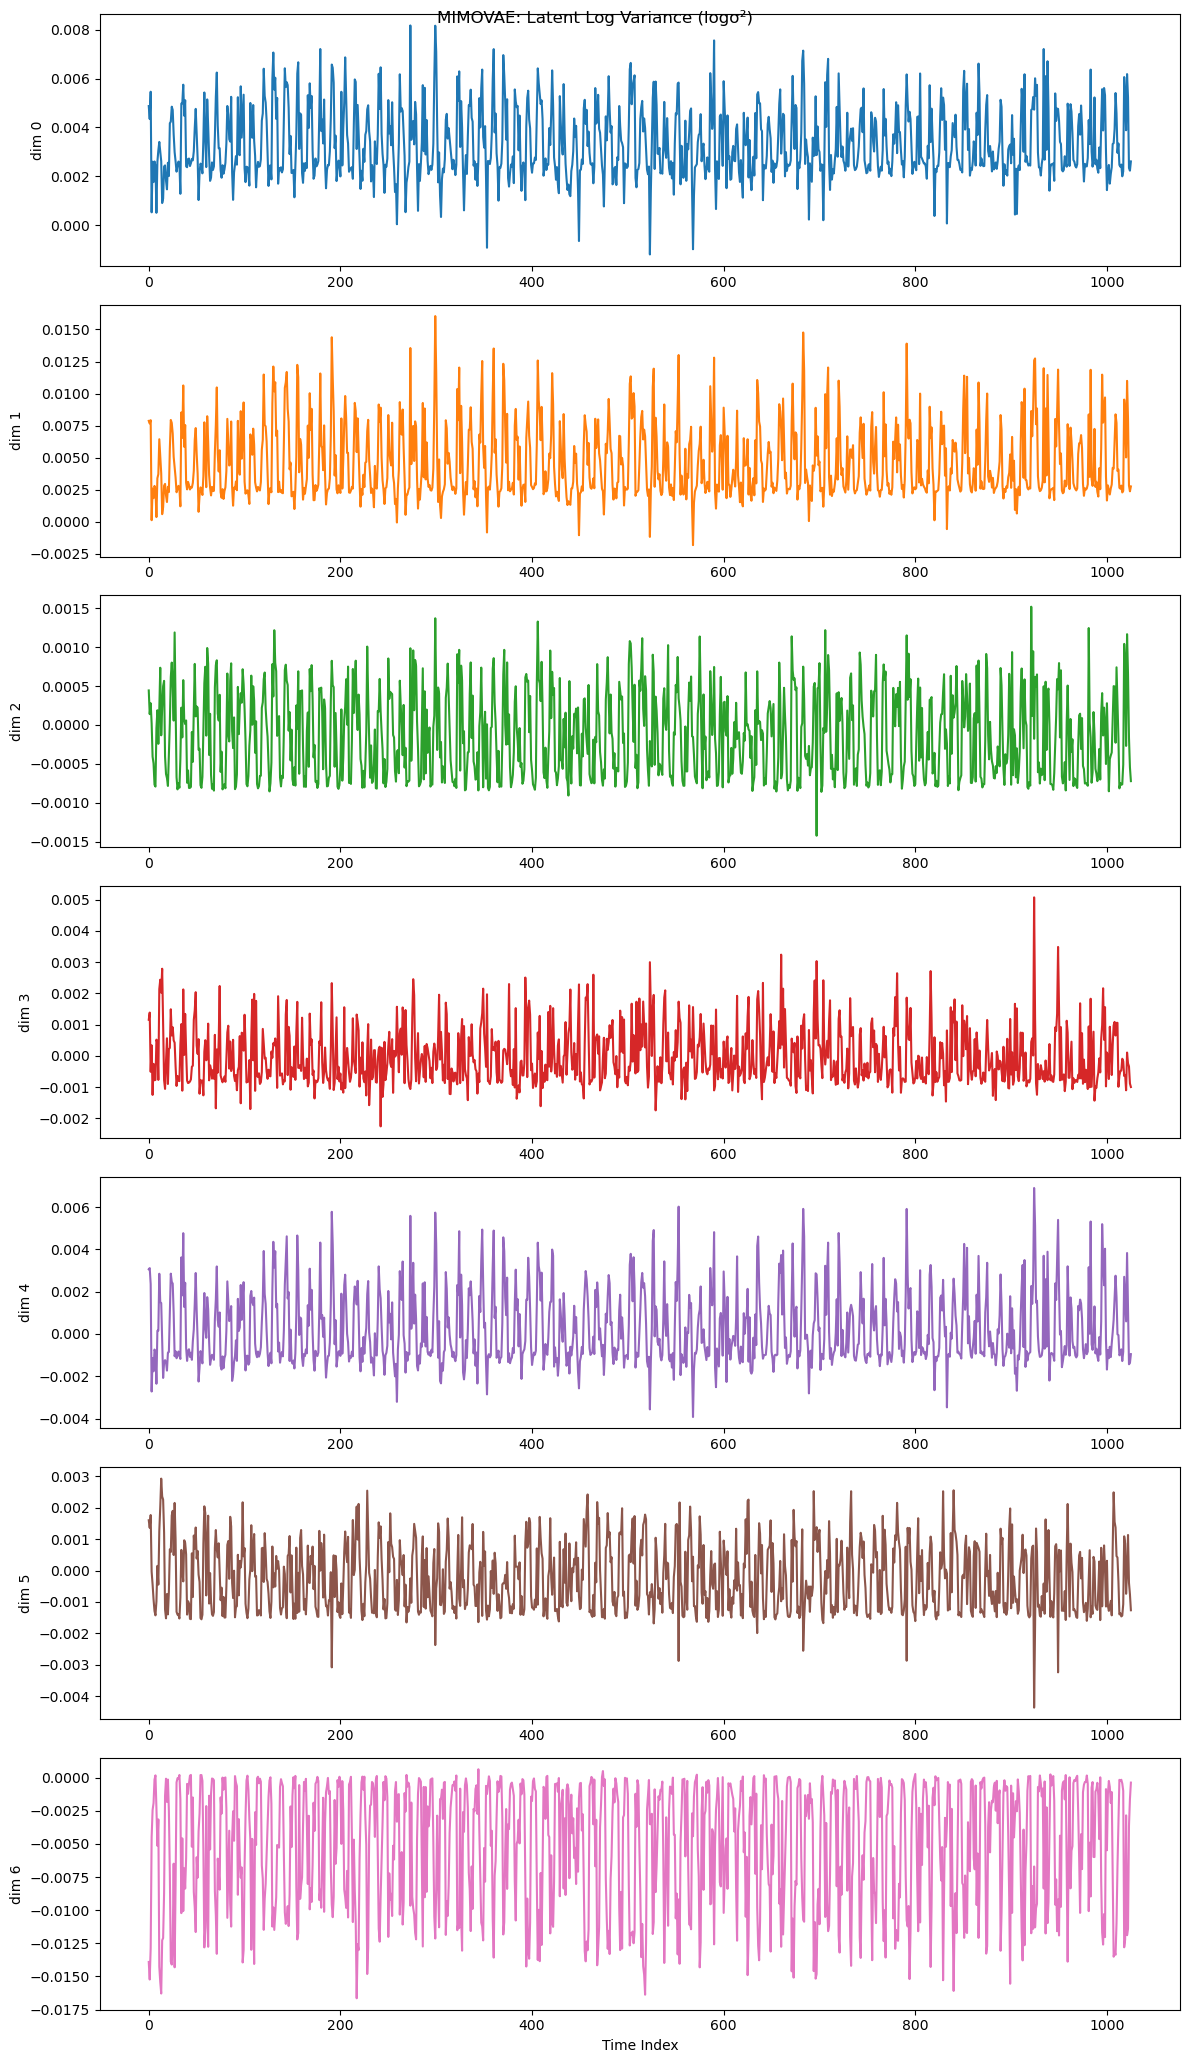

In [11]:
for Dim in range(2, 8):
    print(f"Starting run for Dim={Dim}...")
    mod = learn(sdata1, pdata1, "minmax", 'sst', 'tp', 0.8, 32, 100, Dim)
    train_summary(mod, f'./results/HD_norm/D{Dim}/HD_norm_D{Dim}_training_summary')
    ext = extractr(mod['model'], sdata1, 'sst', pdata1, 'tp', mod['sst_scaler'], mod['precip_scaler'], False, True, f"./results/HD_norm/D{Dim}/HD_norm_D{Dim}_extractr")
    print(f"Completed run for Dim={Dim} ✓\n")

# Running the gammaVAE

In [12]:
from vae_code.HD.gammaVAE_HD import *

In [14]:
for Dim in range(2, 9):
    print(f"Starting run for Dim={Dim}...")
    mod = learn(sdata1, pdata1, "minmax", 'sst', 'tp', 1, 2, 0.8, 32, 100, Dim)
    train_summary(mod, f'./results/HD_gamma/D{Dim}/HD_gamma_D{Dim}_training_summary')
    ext = extractr(mod['model'], sdata1, 'sst', pdata1, 'tp', mod['sst_scaler'], mod['precip_scaler'], False, True, f"./results/HD_gamma/D{Dim}/HD_gamma_D{Dim}_extractr")
    print(f"Completed run for Dim={Dim} ✓\n")

Starting run for Dim=8...
Completed run for Dim=8 ✓



# Running the mimoAE

In [23]:
from vae_code.HD.mimoAE_HD import *

In [28]:
from vae_code.HD.mimoAE_HD_new import *

mod = learn(sdata1, pdata1, "minmax", 'sst', 'tp', 0.8, 32, 100, 2)

In [29]:
for Dim in range(2, 9):
    print(f"Starting run for Dim={Dim}...")
    mod = learn(sdata1, pdata1, "minmax", 'sst', 'tp', 0.8, 32, 100, Dim)
    train_summary(mod, f'./results/HD_mimo/D{Dim}/HD_mimo_D{Dim}_training_summary')
    ext = extractr(mod['model'], sdata1, 'sst', pdata1, 'tp', mod['sst_scaler'], mod['precip_scaler'], False, True, f"./results/HD_mimo/D{Dim}/HD_mimo_D{Dim}_extractr")
    print(f"Completed run for Dim={Dim} ✓\n")

Starting run for Dim=2...
Completed run for Dim=2 ✓

Starting run for Dim=3...
Completed run for Dim=3 ✓

Starting run for Dim=4...
Completed run for Dim=4 ✓

Starting run for Dim=5...
Completed run for Dim=5 ✓

Starting run for Dim=6...
Completed run for Dim=6 ✓

Starting run for Dim=7...
Completed run for Dim=7 ✓

Starting run for Dim=8...
Completed run for Dim=8 ✓



# Running PCA on the latent spaces of the normally distributed model

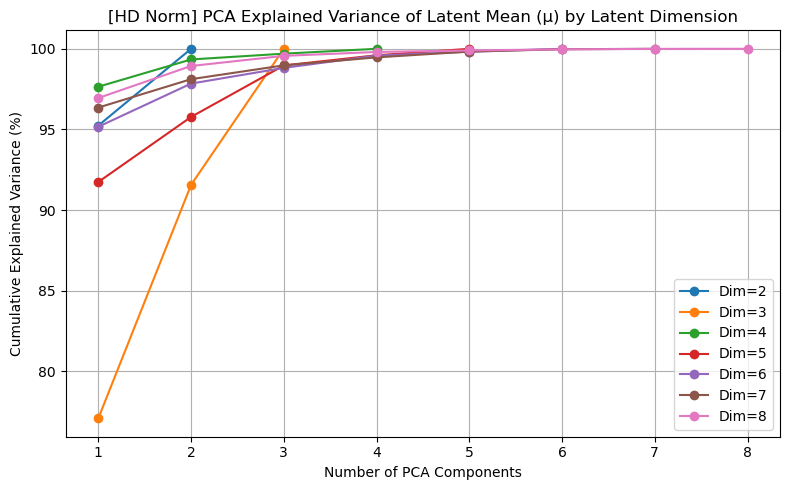

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dims = range(2, 9)
mu_by_dim = {}

for Dim in dims:
    path = f'./results/HD_norm/D{Dim}/HD_norm_D{Dim}_extractr_latent_full.csv'
    df = pd.read_csv(path)
    
    # Pivot to wide format: rows = timesteps, columns = latent dims
    mu_wide = df.pivot(index='time', columns='latent_dim', values='mu')
    mu_by_dim[Dim] = mu_wide.values

# --- Run PCA and plot explained variance ---
fig, ax = plt.subplots(figsize=(8, 5))

for Dim, mu in mu_by_dim.items():
    pca = PCA()
    pca.fit(mu)
    cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(range(1, Dim + 1), cumulative_var, marker='o', label=f'Dim={Dim}')

ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('[HD Norm] PCA Explained Variance of Latent Mean (μ) by Latent Dimension')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('./results/HD_norm/PCA_explained_variance.png', dpi=150)
plt.show()

In [36]:
from sklearn.decomposition import PCA
import pandas as pd

for Dim in range(2, 9):
    path = f'./results/HD_norm/D{Dim}/HD_norm_D{Dim}_extractr_latent_full.csv'
    df = pd.read_csv(path)
    
    mu_wide = df.pivot(index='time', columns='latent_dim', values='latent')
    
    pca = PCA()
    pc_scores = pca.fit_transform(mu_wide.values)
    
    pc_df = pd.DataFrame(
        pc_scores,
        index=mu_wide.index,
        columns=[f'PC{i+1}' for i in range(Dim)]
    )
    pc_df.index.name = 'time'
    pc_df.to_csv(f'./results/HD_norm/D{Dim}/HD_norm_D{Dim}_PCs.csv')
    print(f"Saved PCs for Dim={Dim} ✓")

Saved PCs for Dim=2 ✓
Saved PCs for Dim=3 ✓
Saved PCs for Dim=4 ✓
Saved PCs for Dim=5 ✓
Saved PCs for Dim=6 ✓
Saved PCs for Dim=7 ✓
Saved PCs for Dim=8 ✓


# Running PCA on the gamma distributed model

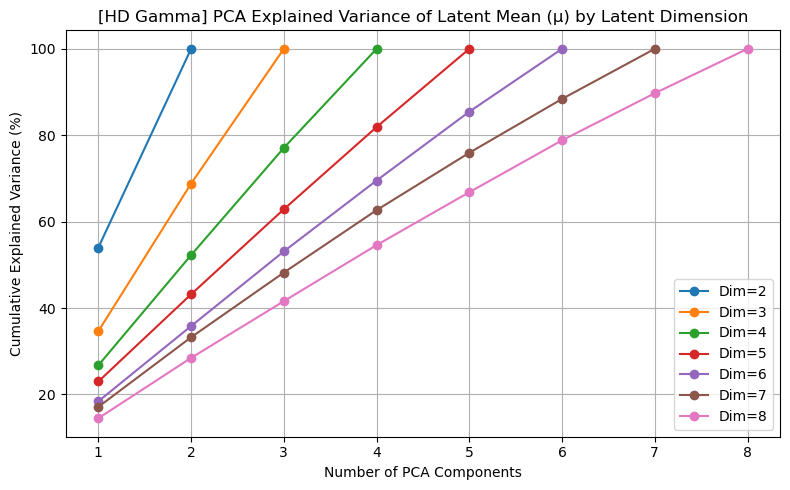

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dims = range(2, 9)
mu_by_dim = {}

for Dim in dims:
    path = f'./results/HD_gamma/D{Dim}/HD_gamma_D{Dim}_extractr_latent_full.csv'
    df = pd.read_csv(path)
    
    # Pivot to wide format: rows = timesteps, columns = latent dims
    mu_wide = df.pivot(index='time', columns='latent_dim', values='latent')
    mu_by_dim[Dim] = mu_wide.values

# --- Run PCA and plot explained variance ---
fig, ax = plt.subplots(figsize=(8, 5))

for Dim, mu in mu_by_dim.items():
    pca = PCA()
    pca.fit(mu)
    cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(range(1, Dim + 1), cumulative_var, marker='o', label=f'Dim={Dim}')

ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('[HD Gamma] PCA Explained Variance of Latent Mean (μ) by Latent Dimension')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('./results/HD_gamma/gamma_PCA_explained_variance.png', dpi=150)
plt.show()

In [35]:
from sklearn.decomposition import PCA
import pandas as pd

for Dim in range(2, 9):
    path = f'./results/HD_gamma/D{Dim}/HD_gamma_D{Dim}_extractr_latent_full.csv'
    df = pd.read_csv(path)
    
    mu_wide = df.pivot(index='time', columns='latent_dim', values='latent')
    
    pca = PCA()
    pc_scores = pca.fit_transform(mu_wide.values)
    
    pc_df = pd.DataFrame(
        pc_scores,
        index=mu_wide.index,
        columns=[f'PC{i+1}' for i in range(Dim)]
    )
    pc_df.index.name = 'time'
    pc_df.to_csv(f'./results/HD_gamma/D{Dim}/HD_gamma_D{Dim}_PCs.csv')
    print(f"Saved PCs for Dim={Dim} ✓")

Saved PCs for Dim=2 ✓
Saved PCs for Dim=3 ✓
Saved PCs for Dim=4 ✓
Saved PCs for Dim=5 ✓
Saved PCs for Dim=6 ✓
Saved PCs for Dim=7 ✓
Saved PCs for Dim=8 ✓


# Running PCA on the deterministic autoencoder

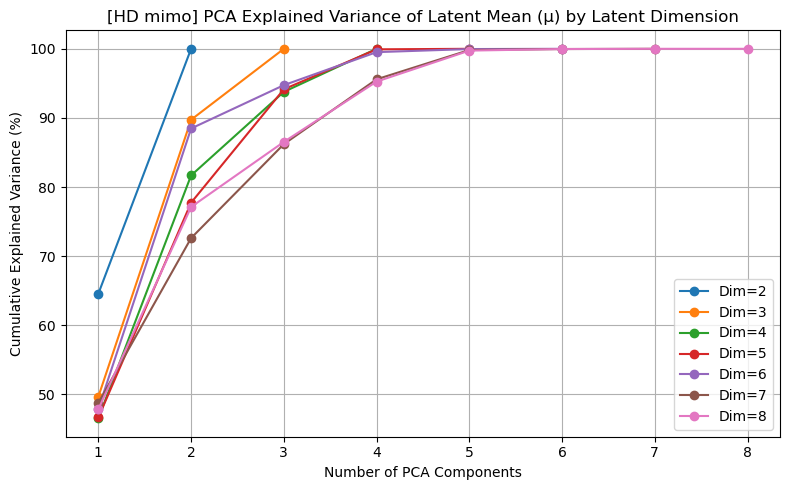

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dims = range(2, 9)
mu_by_dim = {}

for Dim in dims:
    path = f'./results/HD_mimo/D{Dim}/HD_mimo_D{Dim}_extractr_latent.csv'
    df = pd.read_csv(path)
    
    # Pivot to wide format: rows = timesteps, columns = latent dims
    mu_wide = df.pivot(index='time', columns='latent_dim', values='latent')
    mu_by_dim[Dim] = mu_wide.values

# --- Run PCA and plot explained variance ---
fig, ax = plt.subplots(figsize=(8, 5))

for Dim, mu in mu_by_dim.items():
    pca = PCA()
    pca.fit(mu)
    cumulative_var = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(range(1, Dim + 1), cumulative_var, marker='o', label=f'Dim={Dim}')

ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('[HD mimo] PCA Explained Variance of Latent Mean (μ) by Latent Dimension')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('./results/HD_mimo/mimo_PCA_explained_variance.png', dpi=150)
plt.show()

In [34]:
from sklearn.decomposition import PCA
import pandas as pd

for Dim in range(2, 9):
    path = f'./results/HD_mimo/D{Dim}/HD_mimo_D{Dim}_extractr_latent.csv'
    df = pd.read_csv(path)
    
    mu_wide = df.pivot(index='time', columns='latent_dim', values='latent')
    
    pca = PCA()
    pc_scores = pca.fit_transform(mu_wide.values)
    
    pc_df = pd.DataFrame(
        pc_scores,
        index=mu_wide.index,
        columns=[f'PC{i+1}' for i in range(Dim)]
    )
    pc_df.index.name = 'time'
    pc_df.to_csv(f'./results/HD_mimo/HD_mimo_D{Dim}_PCs.csv')
    print(f"Saved PCs for Dim={Dim} ✓")

Saved PCs for Dim=2 ✓
Saved PCs for Dim=3 ✓
Saved PCs for Dim=4 ✓
Saved PCs for Dim=5 ✓
Saved PCs for Dim=6 ✓
Saved PCs for Dim=7 ✓
Saved PCs for Dim=8 ✓
